# 02 — Harpd AI Product Ranking Trends

## Question

What does the Harpd Rank board actually contain, how much paid placement is on it,
and can any trend be measured from the published files?

The third part of that question matters: the word "trends" implies a time series.
This notebook tests whether one exists before computing anything.


## Dataset

| Item | Value |
|---|---|
| Overall board | `data/rankings/overall.json` — 1,122 records |
| Monthly board | `data/rankings/monthly.json` — 1,122 records |
| Weekly board | `data/rankings/weekly.json` — 1,122 records |
| Raw base | `https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/` |
| Licence | CC BY 4.0 |

**Domain caveat.** Rank Points are promotional placement bought with Credits — NOT
an editorial quality score. A higher position means more Credits were spent, not
that a product is better. Harpd's own evidence register lists "that a
higher-ranked product on Harpd Rank is a better product" under `notClaimed`.


## Method

1. Load all three published boards.
2. `analysis.ranking_board_comparison` compares record counts, distinct products,
   placement totals and category coverage across the boards.
3. `analysis.placement_concentration` counts products with `rankPoints > 0`.
4. `analysis.top_placement` returns products carrying points, ordered by points —
   a **promotional placement ordering**.
5. Test explicitly for a time series by reading each file's declared period window,
   and report whether period-over-period comparison is possible.


## Analysis

In [1]:
import os
import sys
from pathlib import Path

# Make the repository root importable no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "harpd_research").is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from harpd_research import analysis, loader

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print("repo root :", ROOT)
print("data base :", loader.resolved_data_base())
print("pandas    :", pd.__version__)
print()
print("DOMAIN CAVEAT")
print(analysis.PLACEMENT_CAVEAT)


repo root : /Users/shankou/harpd/harpd-ai-research-notebooks
data base : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/
pandas    : 3.0.5

DOMAIN CAVEAT
Rank Points are promotional placement bought with Credits — NOT an editorial quality score. Any ordering below is a promotional placement ordering, not a ranking of product quality.


In [2]:
overall = loader.load_ranking("overall")
monthly = loader.load_ranking("monthly")
weekly = loader.load_ranking("weekly")

for label, frame in (("overall", overall), ("monthly", monthly), ("weekly", weekly)):
    print(f"{label:8s} rows={len(frame):,}  generatedAt={frame.attrs.get('generatedAt')}")
    print(f"         periodKey={frame.attrs.get('periodKey')}  "
          f"scope={frame.attrs.get('scope')}")

print()
print("overall periods block:")
for key, value in (overall.attrs.get("periods") or {}).items():
    print(f"  {key}: {value}")

overall  rows=1,122  generatedAt=2026-09-16T10:37:21.290Z
         periodKey=None  scope=overall
monthly  rows=1,122  generatedAt=2026-09-16T10:37:21.290Z
         periodKey=2026-09  scope=None
weekly   rows=1,122  generatedAt=2026-09-16T10:37:21.290Z
         periodKey=2026-W38  scope=None

overall periods block:
  monthStart: 2026-09-01T00:00:00.000Z
  monthEnd: 2026-10-01T00:00:00.000Z
  weekStart: 2026-09-14T00:00:00.000Z
  weekEnd: 2026-09-21T00:00:00.000Z
  monthKey: 2026-09
  weekKey: 2026-W38


In [3]:
comparison = analysis.ranking_board_comparison(overall, monthly, weekly)
display(comparison)

,board,records,distinctProducts,productsWithPlacement,totalRankPoints,categoriesRepresented
0,overall,1122,1122,1,233.0,27
1,monthly,1122,1122,1,233.0,27
2,weekly,1122,1122,1,233.0,27


In [4]:
placement = analysis.placement_concentration(overall)
display(pd.DataFrame([placement]).drop(columns=["caveat"]).T.rename(columns={0: "value"}))

,value
totalProducts,1122
productsWithPlacement,1
productsWithoutPlacement,1121
placementCoveragePct,0.0891
totalRankPoints,233.0
maxRankPoints,233.0
largestPlacementSharePct,100.0
distinctPlacementValues,2
has_meaningful_placement,False


In [5]:
top = analysis.top_placement(overall, n=10)
if top.empty:
    print("No product on the overall board carries any Rank Points.")
    print("There is therefore no placement ordering to display — reported as a")
    print("finding rather than filled in with substitute data.")
else:
    print("PROMOTIONAL PLACEMENT ORDERING (not a quality ranking)")
    display(top)

PROMOTIONAL PLACEMENT ORDERING (not a quality ranking)


,rank,name,categoryName,rankPoints,verified
0,1,imgkit,AI Media,233,True


In [6]:
# Does a time series exist? Compare the declared period windows of each board.
windows = {}
for label, frame in (("overall", overall), ("monthly", monthly), ("weekly", weekly)):
    periods = frame.attrs.get("periods") or {}
    if not periods:
        periods = {
            "periodStart": frame.attrs.get("periodStart"),
            "periodEnd": frame.attrs.get("periodEnd"),
        }
    windows[label] = (periods.get("monthKey") or frame.attrs.get("periodKey"),
                      periods.get("weekKey"))

for label, (month_key, week_key) in windows.items():
    print(f"{label:8s} monthKey={month_key}  weekKey={week_key}")

distinct_periods = set(windows.values())
print()
print("distinct (monthKey, weekKey) tuples across the three files:", len(distinct_periods))
print("snapshots available for period-over-period comparison:",
      "1 (this snapshot only)")
print()
print("CONCLUSION: the three files are three *views* of the same period, not three")
print("points in time. No trend, growth rate or delta can be computed from them.")
print("Historical archives are published separately at https://harpd.com/rank/history/")

overall  monthKey=2026-09  weekKey=2026-W38
monthly  monthKey=2026-09  weekKey=None
weekly   monthKey=2026-W38  weekKey=None

distinct (monthKey, weekKey) tuples across the three files: 3
snapshots available for period-over-period comparison: 1 (this snapshot only)

CONCLUSION: the three files are three *views* of the same period, not three
points in time. No trend, growth rate or delta can be computed from them.
Historical archives are published separately at https://harpd.com/rank/history/


In [7]:
# What fields exist, and what is deliberately absent?
print("columns on a ranking record:")
print(list(overall.columns))
print()
absent = [
    "review score", "traffic", "monthly visits", "revenue", "downloads",
    "user rating", "quality score", "previous rank",
]
print("fields NOT present (so no metric can be derived from them):")
for field in absent:
    print(f"  - {field}")

columns on a ranking record:
['id', 'name', 'slug', 'url', 'category', 'categoryName', 'rank', 'rankPoints', 'verified', 'updatedAt']

fields NOT present (so no metric can be derived from them):
  - review score
  - traffic
  - monthly visits
  - revenue
  - downloads
  - user rating
  - quality score
  - previous rank


## Visualization

Placement coverage across the board. Because the funded share is so small, the
chart is dominated by the unfunded bar — which is the point of showing it.


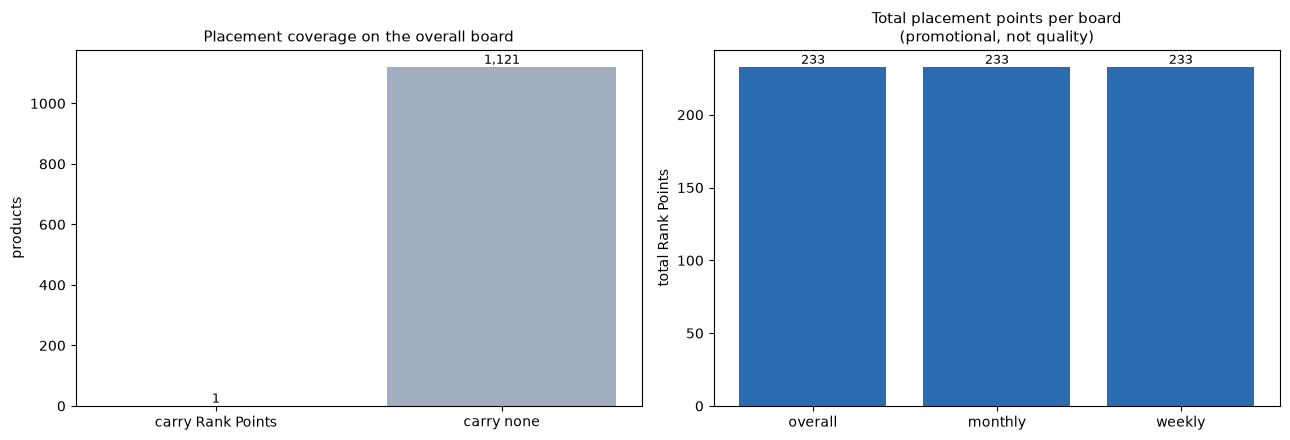

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

labels = ["carry Rank Points", "carry none"]
values = [placement["productsWithPlacement"], placement["productsWithoutPlacement"]]
bars = axes[0].bar(labels, values, color=["#c05621", "#a0aec0"])
axes[0].set_ylabel("products")
axes[0].set_title("Placement coverage on the overall board", fontsize=11)
for bar, v in zip(bars, values, strict=False):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}",
                 ha="center", va="bottom", fontsize=9)

board_labels = list(comparison["board"])
board_points = list(comparison["totalRankPoints"])
axes[1].bar(board_labels, board_points, color="#2b6cb0")
axes[1].set_ylabel("total Rank Points")
axes[1].set_title("Total placement points per board\n(promotional, not quality)", fontsize=11)
for i, v in enumerate(board_points):
    axes[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Findings

Computed below. Note that the headline result is a near-absence of placement, which
is reported as-is.


In [9]:
if top.empty:
    top_line = ("No product on the overall board carries Rank Points, so no "
                "placement ordering exists to display.")
else:
    top_line = (f"{len(top)} product(s) carry placement points; the largest is "
                f"'{top.iloc[0]['name']}' with {int(top.iloc[0]['rankPoints'])} points "
                f"(promotional placement, not quality).")

findings = [
    f"All three boards cover the same {len(overall):,} products, so board size is "
    "identical across overall, monthly and weekly.",

    f"{placement['productsWithPlacement']:,} of {placement['totalProducts']:,} "
    f"products ({placement['placementCoveragePct']}%) hold any Rank Points.",

    f"Total Rank Points on the overall board: {placement['totalRankPoints']:,.0f}.",

    top_line,

    f"{int(overall['verified'].sum())} product(s) on the board are marked verified.",

    "The three files share one period window, so no trend can be measured from "
    "them. Any 'trend' claim would require the separate historical archive.",

    "Because placement coverage is effectively zero, no concentration curve, Gini "
    "coefficient or top-N share is computed. Reporting one would imply a "
    "distribution that does not exist.",
]

for i, line in enumerate(findings, 1):
    print(f"{i}. {line}")

1. All three boards cover the same 1,122 products, so board size is identical across overall, monthly and weekly.
2. 1 of 1,122 products (0.0891%) hold any Rank Points.
3. Total Rank Points on the overall board: 233.
4. 1 product(s) carry placement points; the largest is 'imgkit' with 233 points (promotional placement, not quality).
5. 1 product(s) on the board are marked verified.
6. The three files share one period window, so no trend can be measured from them. Any 'trend' claim would require the separate historical archive.
7. Because placement coverage is effectively zero, no concentration curve, Gini coefficient or top-N share is computed. Reporting one would imply a distribution that does not exist.


## Limitations

- **Rank Points are promotional placement bought with Credits — NOT an editorial
  quality score.** A higher position means more Credits were spent.
- Harpd's evidence register explicitly lists as `notClaimed`: "That a higher-ranked
  product on Harpd Rank is a better product", with the stated reason that Rank
  Points are promotional placement and Harpd holds no quality measurement that
  would support an ordering by merit.
- These boards are live views scoped to the current period window, not historical
  archives. No historical snapshot is bundled here, so no trend is computed.
- The three boards are not independent samples; they are three views of one
  catalog. Comparing them cannot produce a time series.
- No traffic, revenue, review or download metric exists in the data. Absence of a
  product from a board is not evidence about that product.
- The board is ordered by `rank`, and `rankPoints` is zero for all but one record.
  The published `rank` field therefore carries no measurable placement signal for
  1,121 of 1,122 products.


## Reproducibility

In [10]:
import platform
import sys

print("Reproduce this notebook")
print("=" * 60)
print("python :", sys.version.split()[0], "on", platform.platform())
print("pandas :", pd.__version__)
print("data   :", loader.resolved_data_base())
print()
print("From a clean machine:")
print("  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks")
print("  cd harpd-ai-research-notebooks")
print("  python -m venv .venv && . .venv/bin/activate")
print("  pip install -r requirements.txt")
print("  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>")
print()
print("Offline / pinned snapshot:")
print("  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...")


Reproduce this notebook
python : 3.13.12 on macOS-26.6.2-arm64-arm-64bit-Mach-O
pandas : 3.0.5
data   : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/

From a clean machine:
  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks
  cd harpd-ai-research-notebooks
  python -m venv .venv && . .venv/bin/activate
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>

Offline / pinned snapshot:
  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...


## Sources

- Dataset registry: <https://github.com/harpd-dev/harpd-ai-datasets>
- Canonical data home: <https://harpd.com/data/>
- Rank board: <https://harpd.com/rank/>
- Historical archive (publisher): <https://harpd.com/rank/history/>
- Rank methodology (publisher): <https://harpd.com/rank/methodology/>
- Evidence register `notClaimed` entries: `data/evidence/evidence.json`

**Licence.** All Harpd dataset content is published under CC BY 4.0.

**Attribution.** Harpd (<https://harpd.com>).

**Not a source for.** Product quality, traffic, revenue, review scores or
market size. None of those are measured by these datasets, and none are
estimated in this notebook.
